In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
df = pd.read_csv('Churn_Modelling.csv')
print('Shape:', df.shape)
print(df.head())

Shape: (10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63     

In [2]:
print(df.info())
print(df.describe())
print('Missing values:')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB
None
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.0000

In [3]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)
print('Remaining columns:', df.columns.tolist())

Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [4]:
print(df['Exited'].value_counts())
churn_rate = round(df['Exited'].mean() * 100, 2)
print(f'Churn Rate: {churn_rate}%')

Exited
0    7963
1    2037
Name: count, dtype: int64
Churn Rate: 20.37%


C:\Users\Kothapalli Shankar\AppData\Local\Temp\ipykernel_31020\2803300234.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette=['#5DCAA5','#D85A30'])


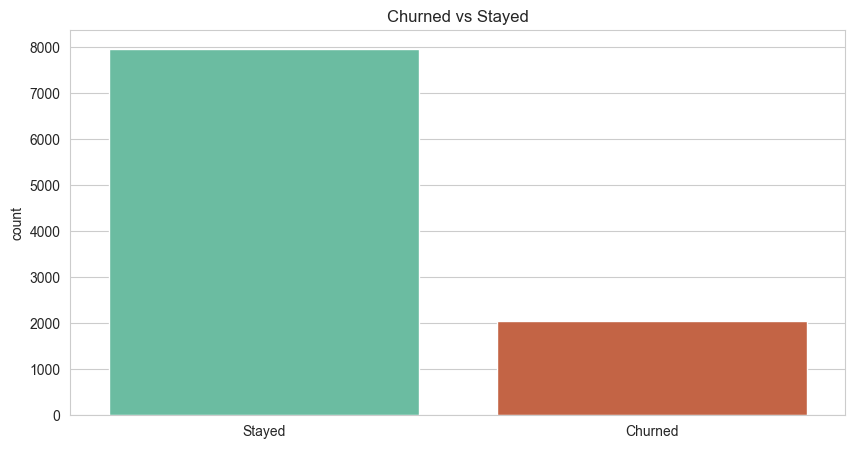

In [5]:
sns.countplot(x='Exited', data=df, palette=['#5DCAA5','#D85A30'])
plt.title('Churned vs Stayed')
plt.xticks([0,1], ['Stayed','Churned'])
plt.xlabel('')
plt.show()

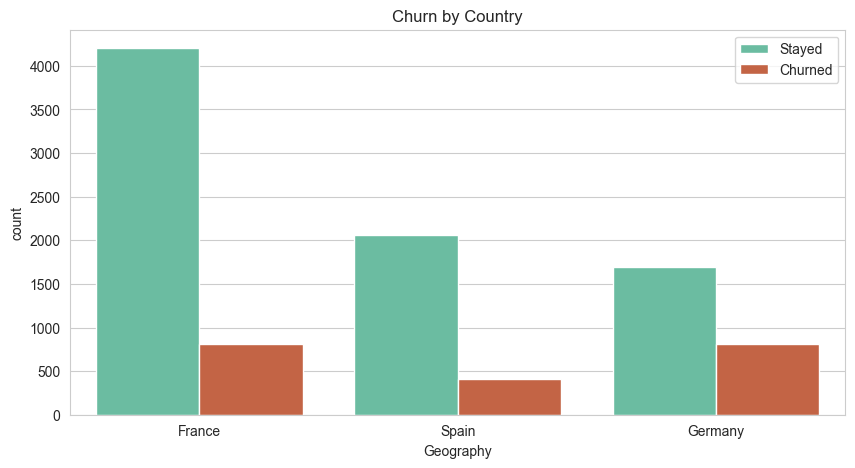

In [6]:
sns.countplot(x='Geography', hue='Exited', data=df,
palette=['#5DCAA5','#D85A30'])
plt.title('Churn by Country')
plt.legend(['Stayed','Churned'])
plt.show()

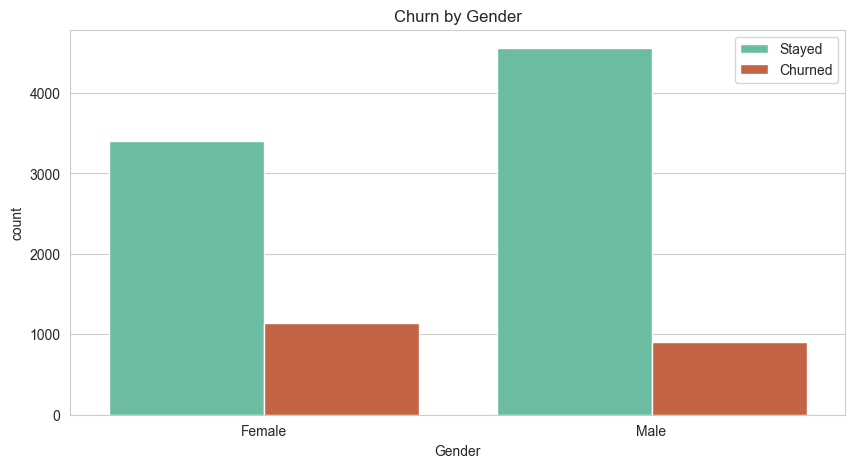

In [7]:
sns.countplot(x='Gender', hue='Exited', data=df,
palette=['#5DCAA5','#D85A30'])
plt.title('Churn by Gender')
plt.legend(['Stayed','Churned'])
plt.show()

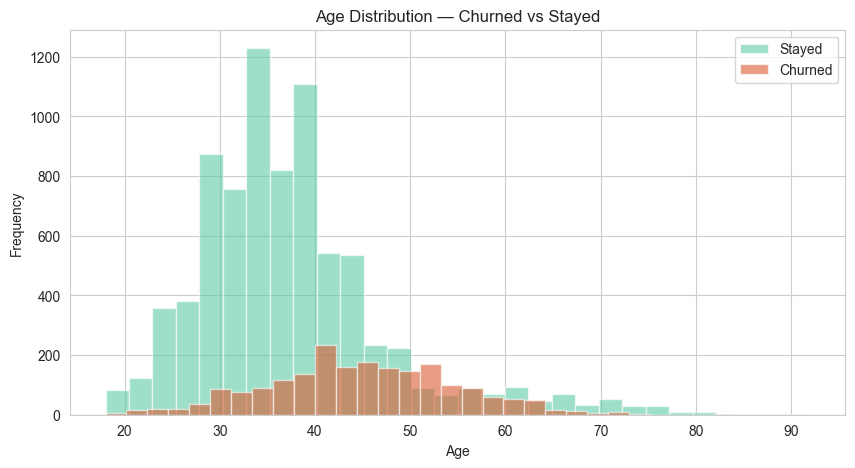

In [8]:
df[df['Exited']==0]['Age'].plot(kind='hist', bins=30,
alpha=0.6, label='Stayed', color='#5DCAA5')
df[df['Exited']==1]['Age'].plot(kind='hist', bins=30,
alpha=0.6, label='Churned', color='#D85A30')
plt.title('Age Distribution — Churned vs Stayed')
plt.xlabel('Age')
plt.legend()
plt.show()

C:\Users\Kothapalli Shankar\AppData\Local\Temp\ipykernel_31020\4269469658.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Balance', data=df,


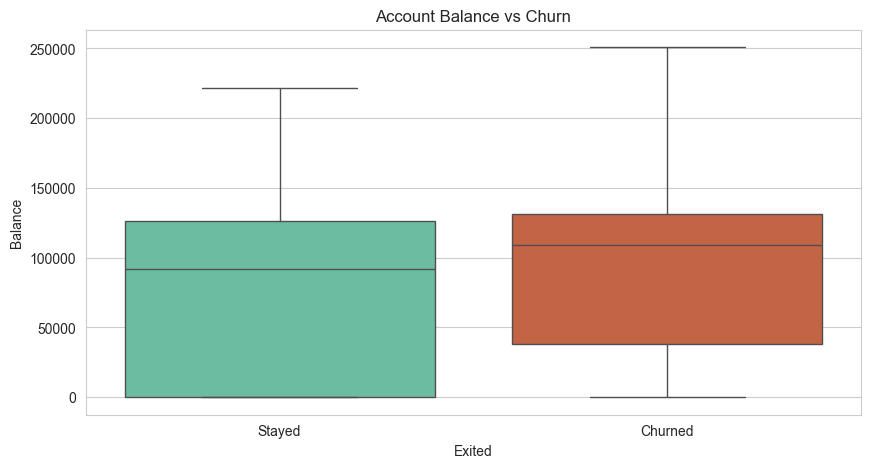

In [9]:
sns.boxplot(x='Exited', y='Balance', data=df,
palette=['#5DCAA5','#D85A30'])
plt.title('Account Balance vs Churn')
plt.xticks([0,1], ['Stayed','Churned'])
plt.show()

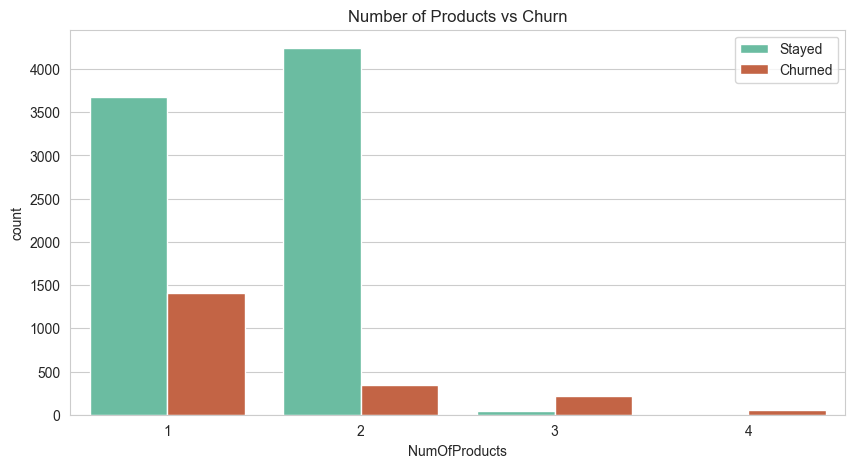

In [10]:
sns.countplot(x='NumOfProducts', hue='Exited',
data=df, palette=['#5DCAA5','#D85A30'])
plt.title('Number of Products vs Churn')
plt.legend(['Stayed','Churned'])
plt.show()

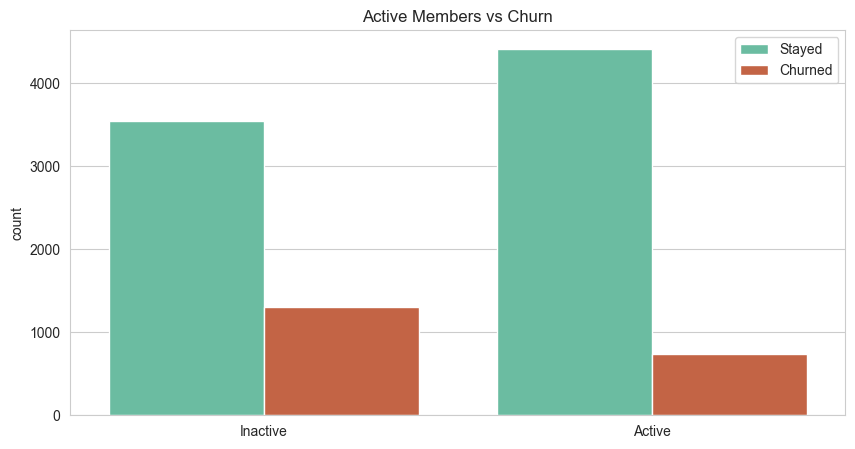

In [11]:
sns.countplot(x='IsActiveMember', hue='Exited',
data=df, palette=['#5DCAA5','#D85A30'])
plt.title('Active Members vs Churn')
plt.xticks([0,1], ['Inactive','Active'])
plt.xlabel('')
plt.legend(['Stayed','Churned'])
plt.show()

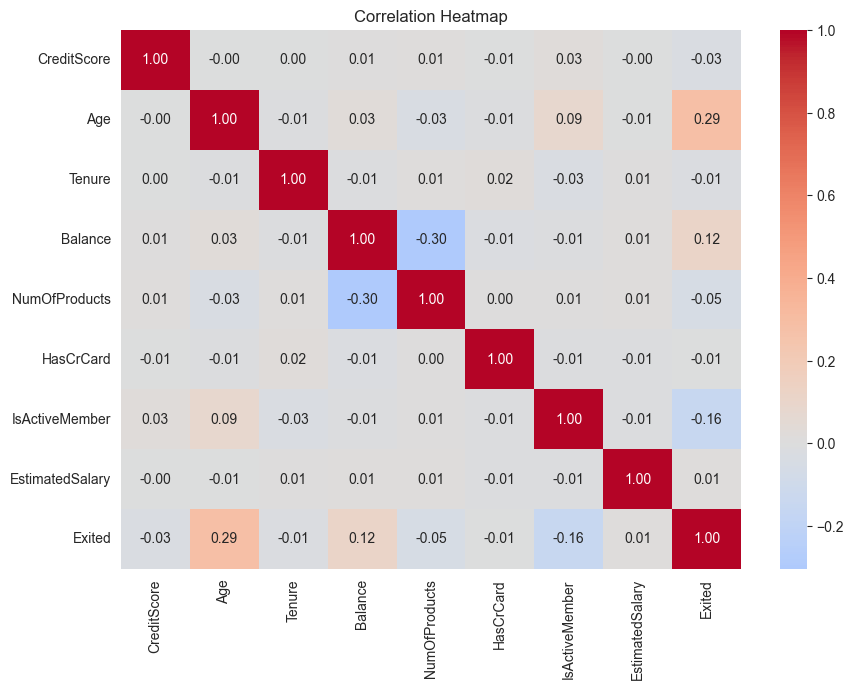

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True,
fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

## Key Findings

- Overall churn rate is ~20% — 1 in 5 customers leave the bank
- Germany has the highest churn (~32%) vs France (16%) and Spain (17%)
- Customers aged 40–60 are the highest churn risk group
- Inactive members churn at nearly 2x the rate of active members
- Customers with 3–4 products have extremely high churn — possibly over-sold
- Female customers churn slightly more than male customers

## Business Recommendations

- Launch targeted retention campaigns for German customers aged 40–60
- Re-engage inactive members with loyalty programmes or personalised offers
- Review product bundling strategy — customers with 3+ products are dissatisfied
- Assign relationship managers to high-balance customers showing inactivity signs